# Static structures tutorial

Sometimes you don't want to wait for gigayears of evolution. You just want to know what a planet of a given mass, entropy, and composition looks like right now: a quick interior profile, a mass-radius point, a sanity check on an EOS choice before you commit to a full run. `ORCHARD`'s initializer and hydrostatic solver can be driven directly from a notebook for exactly this, and each converged structure takes seconds.

In this tutorial we will build static (non-evolving) structures by calling two functions. `initialize_grid()` (`initial.py`) builds the mass mesh, the composition profiles, and a first-guess structure. `hydrostatic_equilibrium(..., init=True)` (`hydrostatic.py`) then relaxes that guess to a converged hydrostatic structure via Henyey relaxation.

**NOTE**: This is "library mode". There is no config file on disk, no `models/` output folder, and nothing is saved. Everything lives in your notebook session.

## How library mode works

When running under Jupyter, `utils/common.py` automatically detects the notebook environment and skips all the command-line and output-folder machinery (you can also force this by setting the environment variable `ORCHARD_LIBRARY_MODE=1`). The configuration is the in-memory `utils.common.config` object, pre-loaded with `parameters_default.ini`, and you override entries by assigning strings, exactly as they would appear in an `.ini` file.

**WARNING**: `initial.py` reads the config at import time. That is when the EOS singletons get built and when structural parameters like `[core].mass_core`, the profile types, and `rk4_initial` get frozen. So the order of operations matters: mutate `common.config` first, then import from `initial`. If you want to change an import-frozen parameter later (say, a different core mass), restart the kernel and rerun. It only costs you the EOS load time. Parameters that are function arguments below (total mass, `S_ini`, `Y_ini`, `Z_ini`) can be varied freely without re-importing.

**NOTE**: We also set `[hydrostatic_equilibrium].hse_adaptive_alpha = False` below. This matches the default, but we pin it explicitly since this notebook depends on it. The optional adaptive damping ramp speeds up well-behaved solves, but for some cold static builds it ramps too eagerly and the Newton iteration walks off to NaN (a 1 M$_J$ model at $S = 6.5$ is one such case). The fixed damping factor of 0.4 takes roughly twice the iterations but converges every time, and for one-off static structures that trade is a no-brainer.

In [1]:
import numpy as np

# ---- 1. Configure the model BEFORE importing initial/hydrostatic ----
from utils import common, const
c = common.config
c["initial"]["M_factor"]  = "317.907"   # 1 M_Jup, in Earth masses
c["initial"]["S_ini"]     = "6.5"       # k_B/baryon (cold, Jupiter-like)
c["initial"]["Y_ini"]     = "0.277"     # protosolar Y/(X+Y)
c["initial"]["Z_ini"]     = "0.02"
c["core"]["mass_core"]    = "10.0"      # 10 M_Earth compact core
c["core"]["mass_core_fe"] = "0.0"       # no iron sub-core
c["hydrostatic_equilibrium"]["rotation"] = "False"
c["hydrostatic_equilibrium"]["hse_adaptive_alpha"] = "False"  # see NOTE above

# ---- 2. Build mass mesh + composition + first-guess structure ----
from initial import initialize_grid          # this triggers 'Loading EOS ...'
from hydrostatic import hydrostatic_equilibrium

N = int(c["general"]["N"])
M_planet = float(c["initial"]["M_factor"]) * const.mearth
r_b0, p0, m_b, dm, S, Y, Z, f_rock, kcore, kcore_fe = initialize_grid(
    N, M_planet,
    float(c["initial"]["S_ini"]), float(c["initial"]["Y_ini"]),
    float(c["initial"]["Z_ini"]), float(c["initial"]["f_rock_ini"]))

# Coreless / no-iron-core sentinels: -1 means "no boundary", which maps to
# index N in ORCHARD's surface->center convention (same normalization as
# evolution.py does at startup).
if kcore == -1:
    kcore = N
if kcore_fe == -1:
    kcore_fe = N

# ---- 3. Henyey relaxation -> converged static structure ----
r_b, p, rho, temp, S, g, omega, j2n, shapes, niter = hydrostatic_equilibrium(
    S, np.log(r_b0), np.log(p0), m_b, Y, Z, f_rock, kcore, kcore_fe,
    omega_prev=0.0, time_sc=0.0, logt_old=np.zeros_like(S), init=True)

print(f"converged in {niter} Henyey iterations")
print(f"R_p   = {r_b[0]/const.rjup:.4f} R_Jup   P_c = {p[-1]*1e-12:.2f} Mbar")
print(f"T_c   = {temp[-1]:.0f} K   rho_c = {rho[-1]:.2f} g/cc   kcore = {kcore}")

Loading EOS ...
Ready!
converged in 110 Henyey iterations
R_p   = 1.0301 R_Jup   P_c = 70.76 Mbar
T_c   = 29835 K   rho_c = 17.38 g/cc   kcore = 443


## Reading the result

A few conventions to keep in mind (they trip up everyone at least once):

- Arrays run outside to inside. Index 0 is the surface and index $N-1$ is the center, so `r_b[0]` is the planetary radius and `p[-1]` is the central pressure.
- Cell-centered arrays (`p`, `rho`, `temp`, `S`, `Y`, `Z`, `f_rock`) have length $N$. Boundary arrays (`r_b`, `m_b`) have length $N+1$, with `m_b[0]` equal to the total mass.
- `kcore` is the index of the envelope-core boundary. Cells with $k \geq$ `kcore` are the rocky interior, handled by the mantle/core EOS.
- `j2n` unpacks as `[J2, J4, J6, J8, oblateness, R_eq, R_pol, MoI]`. These are only meaningful when `rotation = True` with the theory-of-figures machinery active. For our non-rotating model they are zeros, so we'll ignore them here (enable `rotation = True` and `tof_calc = True` for the rotating case; see `parameter_descriptions.md`).

Let's look at the structure we just built.

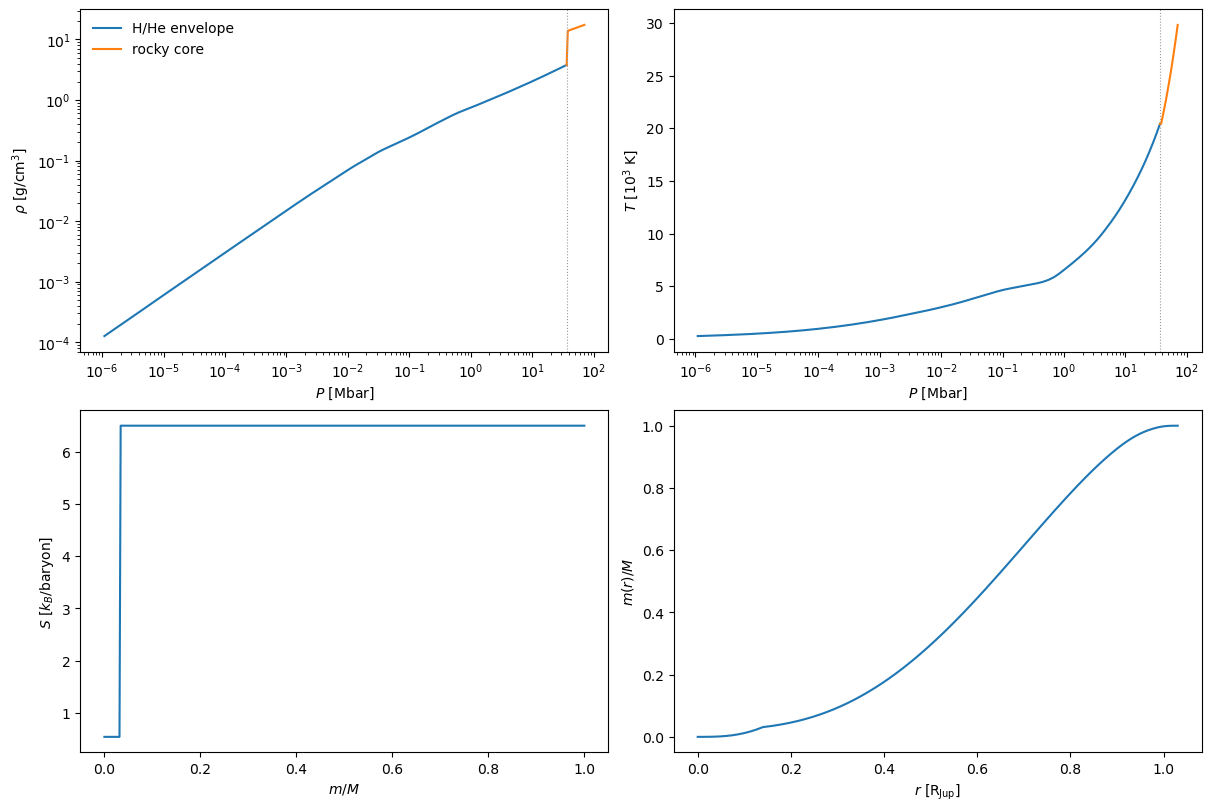

In [2]:
import matplotlib.pyplot as plt

P_Mbar = p * 1e-12                       # dyn/cm^2 -> Mbar
m_norm = m_b[:-1] / m_b[0]               # normalized enclosed mass (cell tops)
env, core = slice(0, kcore), slice(max(kcore - 1, 0), N)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
(ax1, ax2), (ax3, ax4) = axes

ax1.plot(P_Mbar[env], rho[env], label='H/He envelope')
ax1.plot(P_Mbar[core], rho[core], label='rocky core')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel(r'$P$ [Mbar]'); ax1.set_ylabel(r'$\rho$ [g/cm$^3$]')
ax1.legend(frameon=False)

ax2.plot(P_Mbar[env], temp[env] / 1e3)
ax2.plot(P_Mbar[core], temp[core] / 1e3)
ax2.set_xscale('log')
ax2.set_xlabel(r'$P$ [Mbar]'); ax2.set_ylabel(r'$T$ [$10^3$ K]')

ax3.plot(m_norm, S)
ax3.set_xlabel(r'$m/M$'); ax3.set_ylabel(r'$S$ [$k_B$/baryon]')

ax4.plot(r_b / const.rjup, m_b / m_b[0])
ax4.set_xlabel(r'$r$ [R$_{\rm Jup}$]'); ax4.set_ylabel(r'$m(r)/M$')

for ax in (ax1, ax2):
    if 0 < kcore < N:
        ax.axvline(P_Mbar[kcore - 1], color='0.6', lw=0.8, ls=':')
plt.show()

The envelope rides the $S = 6.5$ k$_B$/baryon adiabat down to the envelope-core boundary (dotted line), where the density jumps onto the rocky-core EOS. The entropy panel is flat in the envelope, since this is a homogeneous, adiabatic starting model, and drops to the separately set core entropy inside `kcore`.

## Varying the composition

Total mass, entropy, helium, and metallicity are arguments of `initialize_grid()`, so we can scan them without touching the frozen config. Let's raise the envelope metallicity and watch the structure compress. More metals at fixed entropy means a denser, more compact planet.

Ready!
Ready!
Ready!


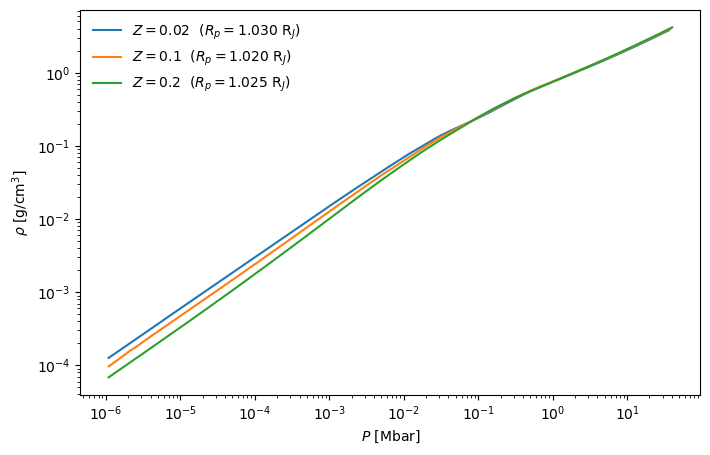

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

for z in [0.02, 0.10, 0.20]:
    out = initialize_grid(N, M_planet, 6.5, 0.277, z,
                          float(c["initial"]["f_rock_ini"]))
    r_b0z, p0z, m_bz, dmz, Sz, Yz, Zz, frz, kc, kcfe = out
    kc = N if kc == -1 else kc
    kcfe = N if kcfe == -1 else kcfe
    r_bz, pz, rhoz, tempz, Sz, gz, omz, j2nz, shz, itz = hydrostatic_equilibrium(
        Sz, np.log(r_b0z), np.log(p0z), m_bz, Yz, Zz, frz, kc, kcfe,
        omega_prev=0.0, time_sc=0.0, logt_old=np.zeros_like(Sz), init=True)
    ax.plot(pz[:kc] * 1e-12, rhoz[:kc],
            label=f'$Z = {z}$  ($R_p = {r_bz[0]/const.rjup:.3f}$ R$_J$)')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$P$ [Mbar]'); ax.set_ylabel(r'$\rho$ [g/cm$^3$]')
ax.legend(frameon=False)
plt.show()

**NOTE**: To vary `[core].mass_core` (or the profile types, or `rk4_initial`), you must restart the kernel, since those are read at import time as warned above. A quick scan over core masses is left as an exercise to the reader. `importlib.reload` chains through `initial.py` are possible but fragile, and a kernel restart is honestly faster.

## A static mass-radius curve

My favorite use of static structures is a mass-radius relation in under a minute. We fix the entropy and composition and scan the total mass. Remember that these are radii at the chosen entropy. A hot (high-$S$) planet is puffy, so think of each point as a snapshot early in the cooling history, not a 4.5-Gyr radius. Lower `S_ini` for colder, older-looking planets, or run the real evolution (see `tutorial_superjupiters.ipynb`) for radii at a given age. All these models keep the 10 M$_\oplus$ core we froze at import.

In [ ]:
masses_mj = [0.3, 0.5, 1.0, 2.0, 3.0, 5.0]
radii_rj = []

for mmj in masses_mj:
    Mp = mmj * const.mjup
    out = initialize_grid(N, Mp, 6.5, 0.277, 0.02,
                          float(c["initial"]["f_rock_ini"]))
    r_b0m, p0m, m_bm, dmm, Sm, Ym, Zm, frm, kc, kcfe = out
    kc = N if kc == -1 else kc
    kcfe = N if kcfe == -1 else kcfe
    r_bm, pm, rhom, tempm, Sm, gm, omm, j2nm, shm, itm = hydrostatic_equilibrium(
        Sm, np.log(r_b0m), np.log(p0m), m_bm, Ym, Zm, frm, kc, kcfe,
        omega_prev=0.0, time_sc=0.0, logt_old=np.zeros_like(Sm), init=True)
    radii_rj.append(r_bm[0] / const.rjup)
    print(f"{mmj:4.1f} M_J -> {radii_rj[-1]:.4f} R_J ({itm} iterations)")

plt.figure(figsize=(8, 5))
plt.plot(masses_mj, radii_rj, 'o-')
plt.xlabel(r'Mass [M$_{\rm Jup}$]')
plt.ylabel(r'Radius [R$_{\rm Jup}$]')
plt.title(r'Static M-R at $S = 6.5\,k_B$/baryon, $Z = 0.02$')
plt.minorticks_on()
plt.show()

Ready!
 0.3 M_J -> 0.9158 R_J (102 iterations)
Ready!
 0.5 M_J -> 0.9680 R_J (116 iterations)
Ready!
 1.0 M_J -> 1.0301 R_J (148 iterations)
Ready!
 2.0 M_J -> 1.0707 R_J (160 iterations)


The familiar flat top of the giant-planet M-R relation emerges already in these static models. Above roughly a Jupiter mass, added mass compresses the interior (H/He is close to an $n \approx 1$ polytrope) instead of growing the radius.

## Where the first guess comes from: `rk4_initial`

`initialize_grid()` needs a starting structure for the Henyey relaxation to polish. With `[initial].rk4_initial = True` (the default), `ORCHARD` builds it by RK4 shooting, integrating the structure equations inward while bisecting on the central pressure until the surface boundary condition is met (`rk4_initial.py`). With `rk4_initial = False`, it instead rescales a stored $S = 9$ Jupiter isentrope, which is fine near a Jupiter mass and cruder elsewhere. Either way, the Henyey relaxation converges to the same hydrostatic answer. A better first guess just gets there in fewer iterations.

## The no-code alternative

**NOTE**: You can also get a static structure without writing any Python. Set `final_age` to a tiny value (e.g. `1e-9`) in a config file and run `evolution.py` normally. The run converges the initial structure, saves exactly one snapshot, and exits, giving you a `models/<config>/` folder you can load with `load_models` and `plot_class` like any other run. Be aware this is emergent behavior rather than a supported "static mode" flag, so treat it as the quick-and-dirty route. The library-mode recipe above is the intended one.

## Exercises

1. Build a static 6 M$_\oplus$ sub-Neptune. Restart the kernel, set `mass_core = 5.4`, `mass_core_fe = 1.7982`, `mantle_comp = mgsio3`, and the composition values from `tutorial_subneptunes_superearths.ipynb`, then rebuild. Compare its central pressure to the Jupiter model's.
2. Compare the CD21 and CMS19 H-He EOSes (`[equation_of_state].hhe_eos = cd` vs `cms`, import-frozen, so one kernel restart each) at fixed mass and entropy. How much does the central temperature move?
3. Redo the M-R curve at $S = 8.5$ k$_B$/baryon and overplot both. The gap between the two curves *is* the cooling contraction that the full evolution code integrates through time.